## **0. Settings**

In [1]:
import os, sys
sys.path.append(os.path.abspath('..'))

## **1. Import Libraries**

In [13]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from src.preprocessing import cleaner, tokenizer

## **2. Get the Data**

In [3]:
it_ai_human_df = pd.read_csv('../data/it_ai_human_data.csv')
it_ai_human_df.head()

,url,source,author,publish_date,text,original_text,generated_type,label
0,https://vietnamnet.vn/nen-mua-iphone-17e-gia-r...,ictnews_vietnamnet,VietNamNet News; Hải Phong,2026-03-05,Sự xuất hiện của iPhone 17e đánh dấu bước tiếp...,NaN,human,0
1,NaN,NaN,NaN,NaN,"Trong Web3, khái niệm về danh tính đang được x...",NaN,generated,1
2,https://quantrimang.com/cong-nghe/cach-kiem-tr...,quantrimang,Dương Huyền Na,2026-06-25,**Hướng dẫn chi tiết cách kiểm tra phiên bản M...,Không chỉ riêng mình bạn mà nhiều người dùng k...,rewrited,1
3,https://vietnamnet.vn/hang-tram-trieu-iphone-c...,ictnews_vietnamnet,VietNamNet News; Hải Phong,2026-03-20,Một chiến dịch tấn công mạng tinh vi mới đang ...,NaN,human,0
4,https://quantrimang.com/cong-nghe/cach-su-dung...,quantrimang,Bá Điền,2026-04-01,Để có thể xem lại những bài viết đã đăng trên ...,Để xem lại tin Facebook đã đăng thì bạn cần ph...,rewrited,1


## **3. Clean Text**

In [4]:
# Test case
text = " >>> Xem ngay  tại: https://openai.com hoặc https://example.com/news?id=123 <p><b>Xin chào</b>, đây là <a href='#'>một bài viết</a>.</p> "
cleaned_text = cleaner.clean_text(text)
cleaned_text

'>>> Xem ngay tại: hoặc Xin chào, đây là một bài viết.'

In [5]:
it_ai_human_df['cleaned_text'] = it_ai_human_df['text'].apply(lambda x: cleaner.clean_text(x))
it_ai_human_df.head()

,url,source,author,publish_date,text,original_text,generated_type,label,cleaned_text
0,https://vietnamnet.vn/nen-mua-iphone-17e-gia-r...,ictnews_vietnamnet,VietNamNet News; Hải Phong,2026-03-05,Sự xuất hiện của iPhone 17e đánh dấu bước tiếp...,NaN,human,0,Sự xuất hiện của iPhone 17e đánh dấu bước tiếp...
1,NaN,NaN,NaN,NaN,"Trong Web3, khái niệm về danh tính đang được x...",NaN,generated,1,"Trong Web3, khái niệm về danh tính đang được x..."
2,https://quantrimang.com/cong-nghe/cach-kiem-tr...,quantrimang,Dương Huyền Na,2026-06-25,**Hướng dẫn chi tiết cách kiểm tra phiên bản M...,Không chỉ riêng mình bạn mà nhiều người dùng k...,rewrited,1,**Hướng dẫn chi tiết cách kiểm tra phiên bản M...
3,https://vietnamnet.vn/hang-tram-trieu-iphone-c...,ictnews_vietnamnet,VietNamNet News; Hải Phong,2026-03-20,Một chiến dịch tấn công mạng tinh vi mới đang ...,NaN,human,0,Một chiến dịch tấn công mạng tinh vi mới đang ...
4,https://quantrimang.com/cong-nghe/cach-su-dung...,quantrimang,Bá Điền,2026-04-01,Để có thể xem lại những bài viết đã đăng trên ...,Để xem lại tin Facebook đã đăng thì bạn cần ph...,rewrited,1,Để có thể xem lại những bài viết đã đăng trên ...


## **4. Tokenize Text**

In [35]:
it_ai_human_df['tokens'] = it_ai_human_df['cleaned_text'].apply(
    lambda x: tokenizer.tokenizer(
        x,
        max_length=512,
        truncation=True,
        padding='max_length',
        return_tensors='pt'
    )['input_ids']
)

In [36]:
it_ai_human_df.head()

,url,source,author,publish_date,text,original_text,generated_type,label,cleaned_text,tokens,token_length
0,https://vietnamnet.vn/nen-mua-iphone-17e-gia-r...,ictnews_vietnamnet,VietNamNet News; Hải Phong,2026-03-05,Sự xuất hiện của iPhone 17e đánh dấu bước tiếp...,NaN,human,0,Sự xuất hiện của iPhone 17e đánh dấu bước tiếp...,"[[tensor(0), tensor(2470), tensor(621), tensor...",1064
1,NaN,NaN,NaN,NaN,"Trong Web3, khái niệm về danh tính đang được x...",NaN,generated,1,"Trong Web3, khái niệm về danh tính đang được x...","[[tensor(0), tensor(1222), tensor(7572), tenso...",483
2,https://quantrimang.com/cong-nghe/cach-kiem-tr...,quantrimang,Dương Huyền Na,2026-06-25,**Hướng dẫn chi tiết cách kiểm tra phiên bản M...,Không chỉ riêng mình bạn mà nhiều người dùng k...,rewrited,1,**Hướng dẫn chi tiết cách kiểm tra phiên bản M...,"[[tensor(0), tensor(12322), tensor(8355), tens...",556
3,https://vietnamnet.vn/hang-tram-trieu-iphone-c...,ictnews_vietnamnet,VietNamNet News; Hải Phong,2026-03-20,Một chiến dịch tấn công mạng tinh vi mới đang ...,NaN,human,0,Một chiến dịch tấn công mạng tinh vi mới đang ...,"[[tensor(0), tensor(1591), tensor(823), tensor...",1032
4,https://quantrimang.com/cong-nghe/cach-su-dung...,quantrimang,Bá Điền,2026-04-01,Để có thể xem lại những bài viết đã đăng trên ...,Để xem lại tin Facebook đã đăng thì bạn cần ph...,rewrited,1,Để có thể xem lại những bài viết đã đăng trên ...,"[[tensor(0), tensor(2574), tensor(293), tensor...",570


## **5. Visualize the Data**

In [ ]:
# Create token_length to visualize comparing with max_length
it_ai_human_df['token_length'] = it_ai_human_df['cleaned_text'].apply(
    lambda x: len(
        tokenizer.tokenizer(
            x,
            truncation=False,
            padding=False
        )['input_ids']
    )
)

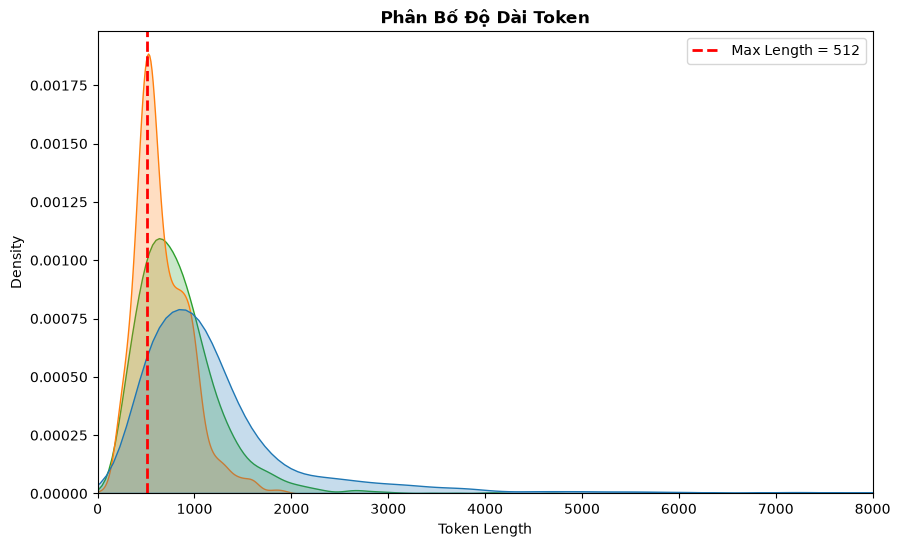

In [39]:
plt.figure(figsize=(10, 6))
sns.kdeplot(
    data=it_ai_human_df,
    x='token_length',
    hue='generated_type',
    fill=True,
    common_norm=False
)
plt.axvline(
    x=512, 
    color='red',
    linestyle='--',
    linewidth=2,
    label='Max Length = 512'
)
plt.title('Phân Bố Độ Dài Token', fontweight='bold')
plt.xlabel('Token Length')
plt.xlim(0, 8000)
plt.ylabel('Density')
plt.legend()
plt.savefig('../figures/preprocessing/token_length_kde_plot.png')
plt.show()